<a href="https://colab.research.google.com/github/Dwayne-tech/DML/blob/main/Artificial_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from __future__ import print_function

import keras
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import RMSprop
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


In [2]:
#Train/Test Split
(train_and_validation_images, train_and_validation_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Construct a validation set from the last 10000 images and labels from
# train_and_validation_images and train_and_validation_labels
validation_images = train_and_validation_images[-10000:, :, :]
validation_labels = train_and_validation_labels[-10000:]

# Construct a training set from the first 50000 images and labels.
train_images = train_and_validation_images[:50000, :, :]
train_labels = train_and_validation_labels[:50000]

In [8]:
# Print shapes
print("Validation images shape:", validation_images.shape)
print("Validation labels shape:", validation_labels.shape)

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)

Validation images shape: (10000, 784)
Validation labels shape: (10000,)
Training images shape: (50000, 784)
Training labels shape: (50000,)


In [4]:
text_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

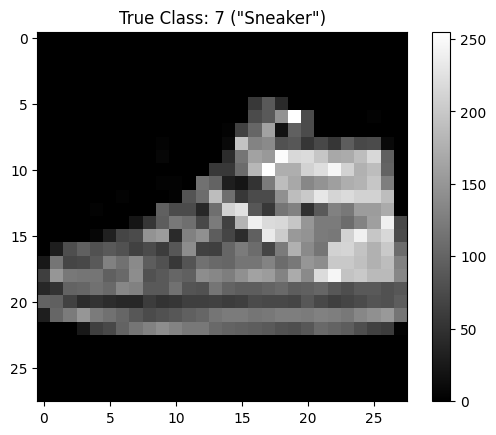

In [5]:
plt.figure()
random_index = np.random.randint(0, len(train_images))
plt.imshow(train_images[random_index], cmap='gray')
plt.colorbar()
numerical_label = train_labels[random_index]
text_description = text_labels[numerical_label]
plt.title('True Class: {} ("{}")'.format(numerical_label, text_description))

plt.gca().grid(False)

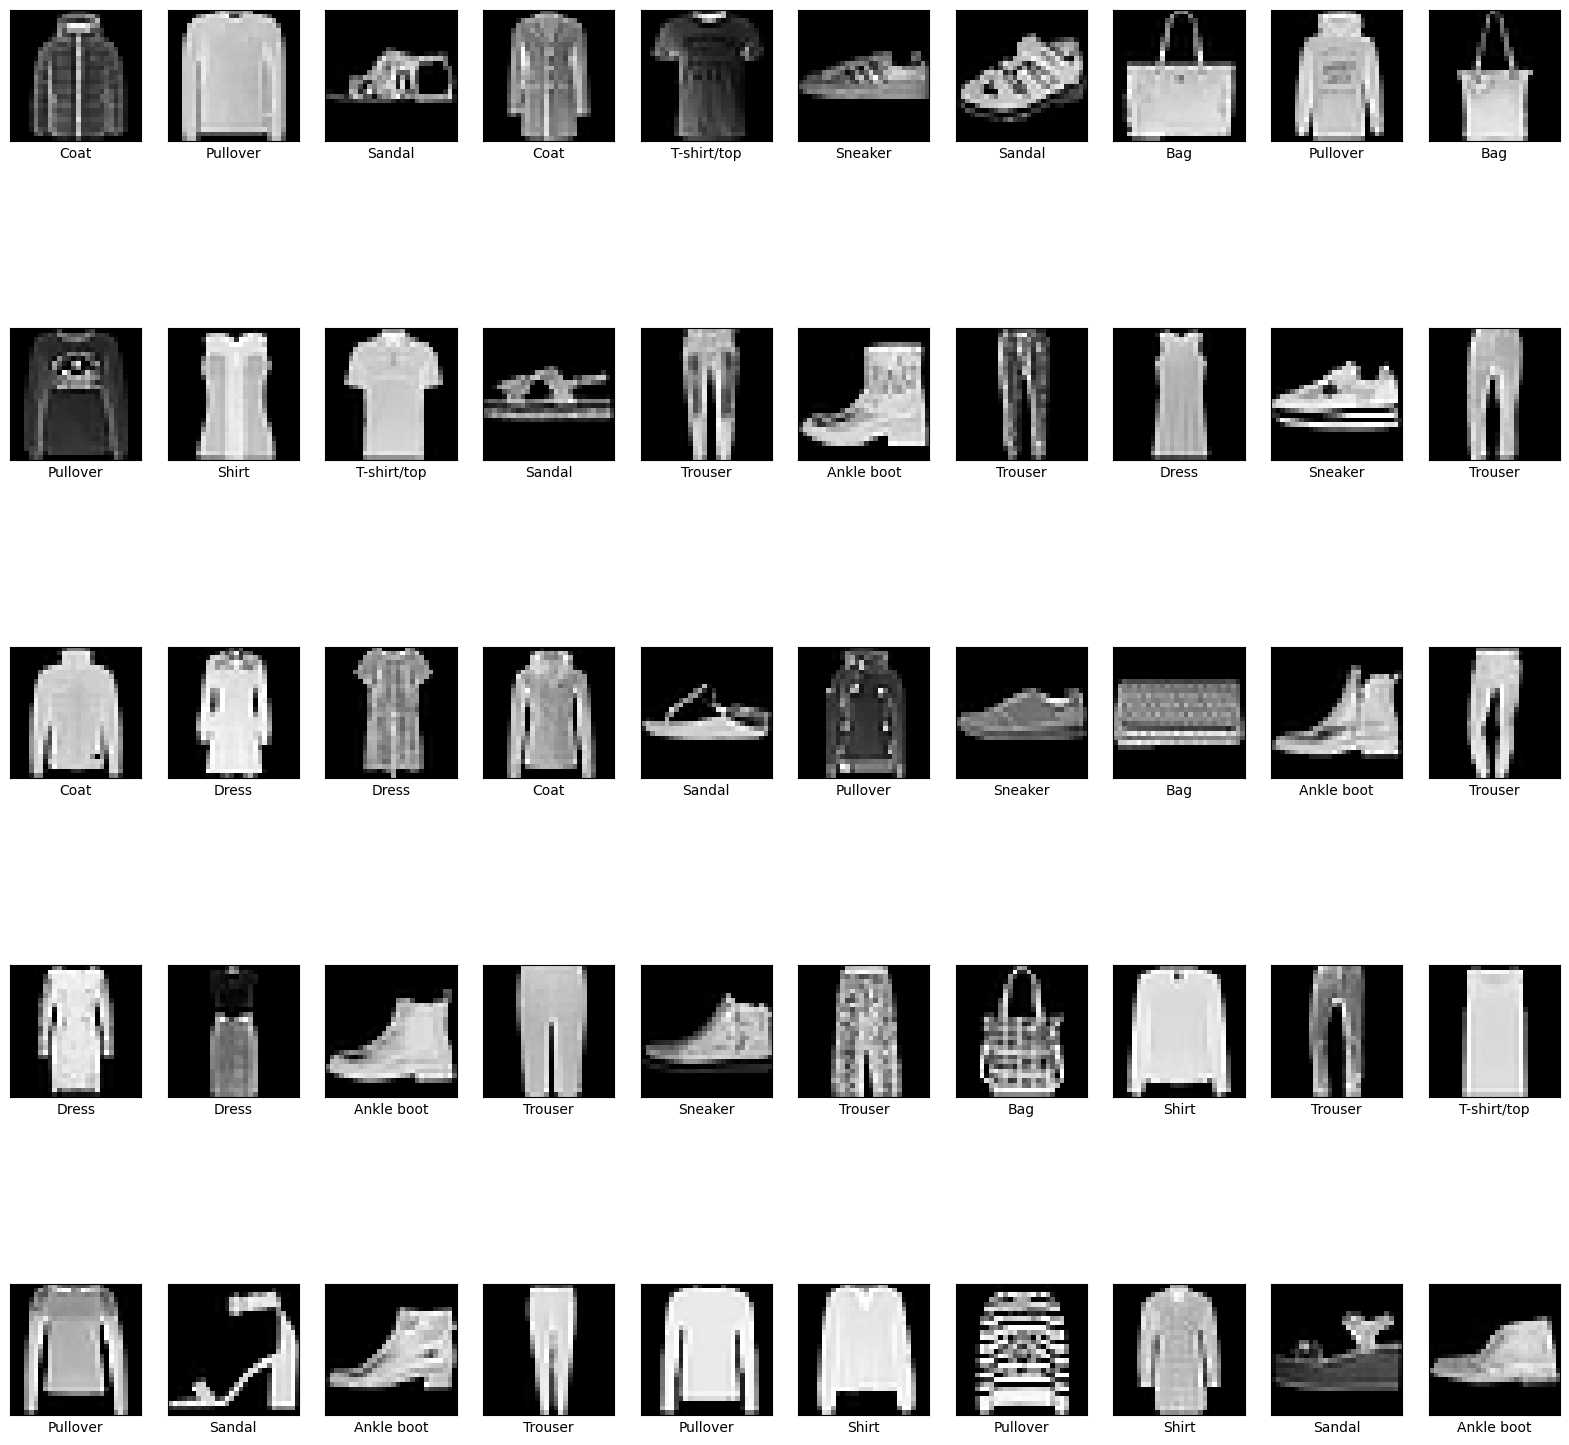

In [6]:
# Another view, showing 50 randomly selected images at a time
plt.figure(figsize=(20,20))
for i in range(50):
    plt.subplot(5,10,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid('off')

    img_index = np.random.randint(0, 50000)
    plt.imshow(train_images[img_index], cmap=plt.cm.gray)
    plt.xlabel(text_labels[train_labels[img_index]])

In [9]:
#Preprocessing
#Flattening the images
train_images_flatten = train_images.reshape(train_images.shape[0], 784)
validation_images_flatten = validation_images.reshape(validation_images.shape[0], -1)
test_images_flatten = test_images.reshape(test_images.shape[0], -1)

In [10]:
# Print the shapes
print(train_images_flatten.shape)
print(validation_images_flatten.shape)
print(test_images_flatten.shape)

(50000, 784)
(10000, 784)
(10000, 784)


In [14]:
#Normalisation
train_images_model = train_images_flatten.astype(np.float32) / 255
validation_images_model = validation_images_flatten.astype(np.float32) / 255.
test_images_model = test_images_flatten.astype(np.float32) / 255

In [17]:

# Verify the shapes
print(validation_images_model.shape)
print(test_images_model.shape)

# Verify the value ranges
print(validation_images_model.min(), validation_images_model.max())
print(test_images_model.min(), test_images_model.max())



(10000, 784)
(10000, 784)
0.0 1.0
0.0 1.0


In [18]:
# convert class vectors to binary class matrices
train_labels_categ = keras.utils.to_categorical(train_labels, 10)
validation_labels_categ = keras.utils.to_categorical(validation_labels, 10)
test_labels_categ = keras.utils.to_categorical(test_labels, 10)

In [20]:
#Train Model
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import fashion_mnist

batch_size = 128
num_classes = 10
epochs = 40

# Create a sequential model
model = keras.Sequential()

# Flatten
model.add(layers.Flatten(input_shape=(784,)))

# Regularization
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dropout(0.2))

# Output layer
model.add(layers.Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# One-hot encoder
train_labels_cat = to_categorical(train_labels, num_classes)
validation_labels_cat = to_categorical(validation_labels, num_classes)

# Train the model
model.fit(train_images_model, train_labels_cat,
          batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(validation_images_model, validation_labels_cat))

# Evaluate the model
test_labels_cat = to_categorical(test_labels, num_classes)
test_loss, test_acc = model.evaluate(test_images_model, test_labels_cat)
print('Test accuracy:', test_acc)

Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7529 - loss: 0.6954 - val_accuracy: 0.8556 - val_loss: 0.3967
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8541 - loss: 0.4000 - val_accuracy: 0.8731 - val_loss: 0.3545
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8667 - loss: 0.3567 - val_accuracy: 0.8757 - val_loss: 0.3416
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8768 - loss: 0.3308 - val_accuracy: 0.8775 - val_loss: 0.3366
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.8867 - loss: 0.3065 - val_accuracy: 0.8822 - val_loss: 0.3256
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8880 - loss: 0.3021 - val_accuracy: 0.8818 - val_loss: 0.3249
Epoch 7/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8942 - loss: 0.2843 - val_accuracy: 0.8834 - val_loss: 0.3192
Epoch 8/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8978 - loss: 0.2731 - val_a

In [23]:
# Test accuracy
score = model.evaluate(test_images_model, test_labels_cat, verbose=0)
print('Test accuracy:', score[1])

Test accuracy: 0.8988999724388123


In [24]:
test_logits = model.predict(test_images_flatten)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [25]:
test_logits

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.99999994],
       [0.        , 0.        , 0.99999994, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.99999994, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.99999994,
        0.        ],
       [0.        , 0.99999994, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)

In [26]:
test_predictions = np.argmax(test_logits, axis=1)

In [27]:
test_predictions

array([9, 2, 1, ..., 8, 1, 5])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


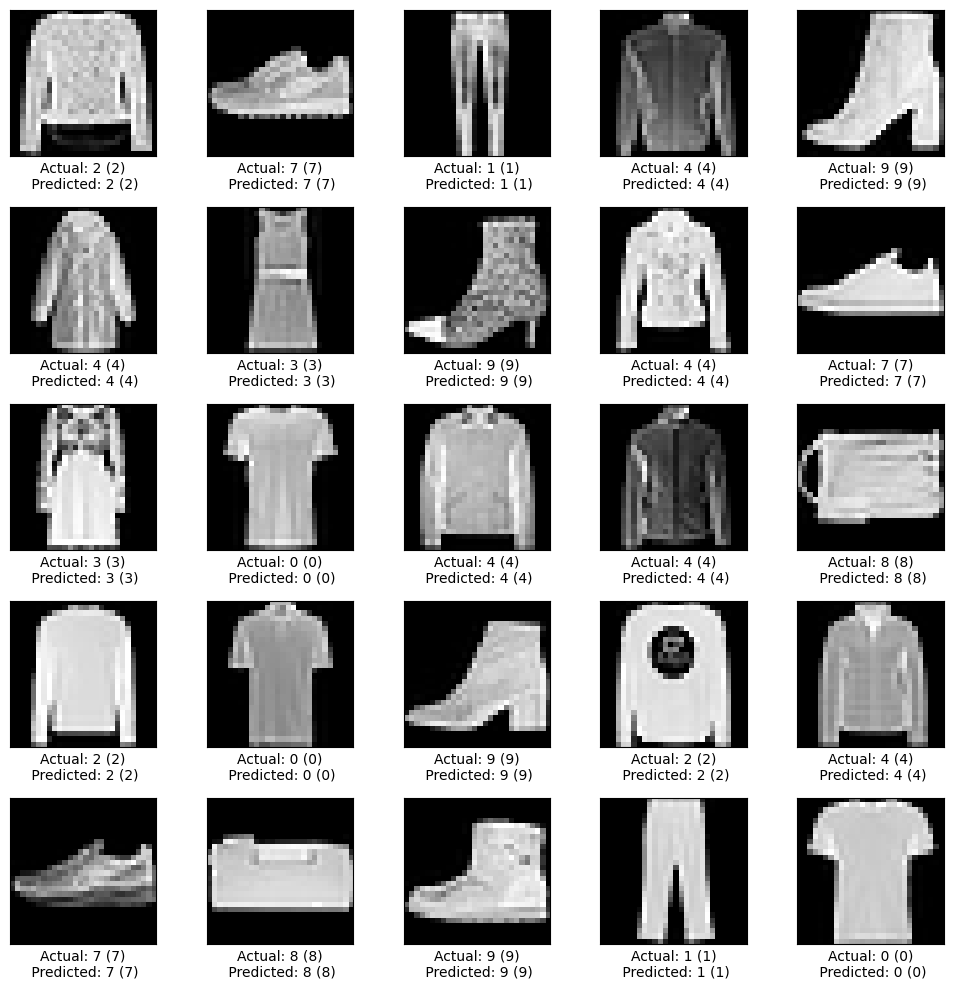

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define the class labels
text_labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# Generate predictions
predictions = model.predict(test_images_model)
predicted_labels = np.argmax(predictions, axis=1)

# Plot the images
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid('off')
    img_index = np.random.randint(0, 10000)
    # Reshape the image
    plt.imshow(test_images[img_index].reshape(28,28), cmap=plt.cm.gray)
    actual_label = int(test_labels[img_index])
    predicted_label = int(predicted_labels[img_index])
    plt.xlabel("Actual: {} ({})\n Predicted: {} ({})".format(
        actual_label, text_labels[actual_label], predicted_label, text_labels[predicted_label]
    ))
plt.tight_layout()
plt.show()

##The multi-layer perceptron has been Implemented and trained with all the random greyscale pictures being displayed above.